**İmporting the CSV file**

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path='/content/drive/My Drive/dirty_credit_customers.csv'
df_csv=pd.read_csv(file_path)
df_csv




Mounted at /content/drive


,CustomerID,FullName,Gender,Age,MaritalStatus,CreditAmount,CreditScore,JoinDate
0,1,Ilkin Hajiyev,Male,20,Divorced,36354,714.0,2021-11-08
1,2,Gunel Mehdiyeva,Female,60,Married,81987,766.0,2021-04-30
2,3,Gunel Mehdiyeva,Female,32,Single,83229,709.0,2024-10-09
3,4,Elvin Mammadli,Male,52,Married,51941,676.0,2020-09-16
4,5,Nigar Huseynli,Female,22,Single,29107,495.0,2023-05-08
...,...,...,...,...,...,...,...,...
995,996,Gunel Mehdiyeva,Female,35,Single,25946,537.0,2023-11-25
996,997,Nigar Huseynli,Female,46,Married,47741,686.0,2021-03-19
997,998,Gunel Mehdiyeva,Female,25,Divorced,1656,784.0,2024-07-21
998,999,Ali Mammadov,Male,61,Divorced,33121,508.0,2022-08-07


**Checking DataFrame Structure and Missing Values**

In [ ]:
# DataFrame strukturu
df_csv.info()

# Boş (NaN) dəyərlərin sayı
print(df_csv.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     1000 non-null   int64  
 1   FullName       1000 non-null   object 
 2   Gender         1000 non-null   object 
 3   Age            1000 non-null   int64  
 4   MaritalStatus  1000 non-null   object 
 5   CreditAmount   1000 non-null   int64  
 6   CreditScore    950 non-null    float64
 7   JoinDate       1000 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 62.6+ KB
CustomerID        0
FullName          0
Gender            0
Age               0
MaritalStatus     0
CreditAmount      0
CreditScore      50
JoinDate          0
dtype: int64


**	Replacing Missing CreditScore with the Median**

In [ ]:
df_csv['CreditScore'] = df_csv['CreditScore'].fillna(df_csv['CreditScore'].median())

**	Cleaning Whitespace from the FullName Field**


In [ ]:

df_csv['FullName'] = df_csv['FullName'].str.strip()
df_csv

,CustomerID,FullName,Gender,Age,MaritalStatus,CreditAmount,CreditScore,JoinDate
0,1,Ilkin Hajiyev,Male,20,Divorced,36354,714.0,2021-11-08
1,2,Gunel Mehdiyeva,Female,60,Married,81987,766.0,2021-04-30
2,3,Gunel Mehdiyeva,Female,32,Single,83229,709.0,2024-10-09
3,4,Elvin Mammadli,Male,52,Married,51941,676.0,2020-09-16
4,5,Nigar Huseynli,Female,22,Single,29107,495.0,2023-05-08
...,...,...,...,...,...,...,...,...
995,996,Gunel Mehdiyeva,Female,35,Single,25946,537.0,2023-11-25
996,997,Nigar Huseynli,Female,46,Married,47741,686.0,2021-03-19
997,998,Gunel Mehdiyeva,Female,25,Divorced,1656,784.0,2024-07-21
998,999,Ali Mammadov,Male,61,Divorced,33121,508.0,2022-08-07



**	Identifying and Removing Outliers in Age Column**

In [ ]:
# Uyğunsuz yaşlara bax
print(df_csv[df_csv['Age'] < 18])
print(df_csv[df_csv['Age'] > 90])

# Yaş 18–90 arasında olmayanları sil
df_csv= df_csv[(df_csv['Age'] >= 18) & (df_csv['Age'] <= 90)]

     CustomerID       FullName  Gender  Age MaritalStatus  CreditAmount  \
42           43  Ilkin Hajiyev    Male  -10        Single         82424   
398         399  Zahra Aliyeva  Female    0       Married         50179   
613         614  Ramil Quliyev    Male    5       Married         51774   
668         669  Zahra Aliyeva  Female    3      Divorced         62568   

     CreditScore    JoinDate  
42         467.0  2023-10-16  
398        318.0  2025-03-30  
613        437.0  2023-01-03  
668        537.0  2020-06-28  
     CustomerID         FullName  Gender  Age MaritalStatus  CreditAmount  \
240         241  Gunel Mehdiyeva  Female  102       Married         63467   
512         513   Nigar Huseynli  Female  120       Married         72771   
699         700   Elvin Mammadli    Male  200       Married         62620   
731         732   Nigar Huseynli  Female   95      Divorced         27766   
840         841  Gunel Mehdiyeva  Female  150        Single         53543   

     C

**Fix Format Errors in the JoinDate Field**

In [ ]:

df_csv.loc[:, 'JoinDate'] = pd.to_datetime(df_csv['JoinDate'], errors='coerce')
df_csv = df_csv.dropna(subset=['JoinDate'])

**Remove Rows Without Valid Dates**

In [ ]:
df_csv = df_csv.dropna(subset=['JoinDate'])

** Replace Missing Dates with a Specific Date**


In [ ]:
df_csv['JoinDate'] = df_csv['JoinDate'].fillna(pd.to_datetime('2020-01-01'))

**Create a New Column Using apply() Based on CreditScore: CreditLevel ("Low", "Medium", "High")**

In [ ]:
def score_level(score):
    if score >= 300 and score <= 579:
        return "Very Poor"       # Çox zəif, risklidir
    elif score >= 580 and score <= 669:
        return "Fair"            # Orta risk
    elif score >= 670 and score <= 739:
        return "Good"            # Yaxşı
    elif score >= 740 and score <= 799:
        return "Very Good"       # Çox yaxşı, etibarlı
    elif score >= 800 and score <= 850:
        return "Excellent"       # Əla, yüksək etibar
    else:
        return "Unknown"         # Aralıq xaricindədirsə

df_csv['CreditLevel'] = df_csv['CreditScore'].apply(score_level)
df_csv[['CreditScore', 'CreditLevel']].head(10)

,CreditScore,CreditLevel
0,714.0,Good
1,766.0,Very Good
2,709.0,Good
3,676.0,Good
4,495.0,Very Poor
5,760.0,Very Good
6,601.0,Fair
7,779.0,Very Good
8,373.0,Very Poor
9,574.0,Very Poor


**Drop Dublicates**

In [ ]:
df_csv.drop_duplicates(inplace=True)

** Cleaning Text Fields (Gender)**

In [ ]:
# Boşluqları təmizlə, kiçik hərfə çevir
df_csv['Gender'] = df_csv['Gender'].str.strip().str.lower()

# Fərqli yazılanları eyni dəyərə çevir
df_csv['Gender'] = df_csv['Gender'].replace({
    'm': 'male',
    'man': 'male',
    'f': 'female',
    'woman': 'female',
    'femail': 'female'
})



**Save the Cleaned File**

In [ ]:
df_csv.to_csv('/content/drive/My Drive/dirty_credit_customers.csv', index=False)
!ls "/content/drive/My Drive/"

'Aysel Nasibova Resume-1-2.pdf'   Dashboard.xlsx
'AYSEL NASIBOVA_копия.pdf'	 'Dax functions.txt'
 Classroom			  dirty_credit_customers.csv
'Colab Notebooks'		 'Ecommerce Purchases.csv'
 customer_data_dirty.csv	  SQL-1.gdoc


 **Exploratory Data Analysis (EDA): Distribution of Credit Scores

The histogram shows how credit scores are distributed among customers, visualizing how many customers fall into each score range **

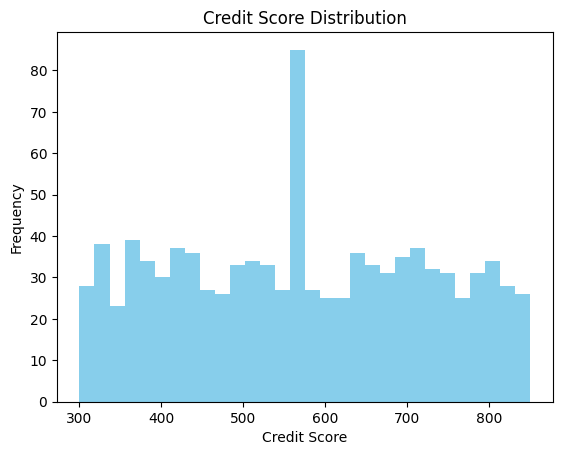

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_csv['CreditScore'], bins=30, color='skyblue')
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df_csv
df_csv['CreditScore'] = df_csv.groupby('CreditLevel')['CreditScore'].transform(lambda x: x.fillna(x.mean()))

In [ ]:
 df_csv['CreditScore'] = df_csv['CreditScore'].astype(int)

**Age Distribution of Customers**

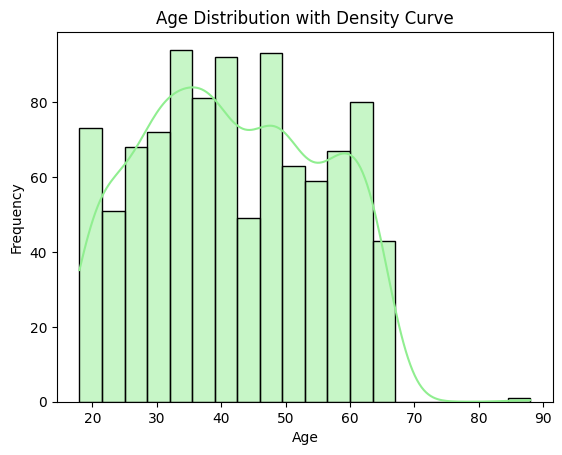

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df_csv, x='Age', bins=20, kde=True, color='lightgreen')
plt.title('Age Distribution with Density Curve')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()